In [14]:
using Revise, JLD2, CairoMakie, LaTeXStrings
includet("Utils.jl")
using .Utils
includet("FigureStyles.jl")
using .FigureStyles
set_theme!(DoubleColumnTheme)

In [18]:
function retrieve_LS_KSE_KYD(motif_data, g_idx::Int64)
    raw_data = motif_data.data
    data_slice = raw_data[:, g_idx]
    len = length(data_slice)

    Lmax_mean = fill(NaN, len)
    Lmax_std = fill(NaN, len)
    PR_mean = fill(NaN, len)
    PR_std = fill(NaN, len)
    H_mean = fill(NaN, len)
    H_std = fill(NaN, len)
    KYD_mean = fill(NaN, len)
    KYD_std = fill(NaN, len)

    for i in 1:len
        entry = data_slice[i]

        if !isnothing(entry)
            # Lmax is the first element of the spectrum
            Lmax_mean[i] = entry.LS_mean[1]
            Lmax_std[i] = entry.LS_std[1]

            PR_mean[i] = entry.PR_mean
            PR_std[i] = entry.PR_std

            H_mean[i] = entry.H_mean
            H_std[i] = entry.H_std

            KYD_mean[i] = entry.KYD_mean
            KYD_std[i] = entry.KYD_std
        end
    end
    return (Lmax_mean, Lmax_std, H_mean, H_std, KYD_mean, KYD_std, PR_mean, PR_std)
end

retrieve_LS_KSE_KYD (generic function with 1 method)

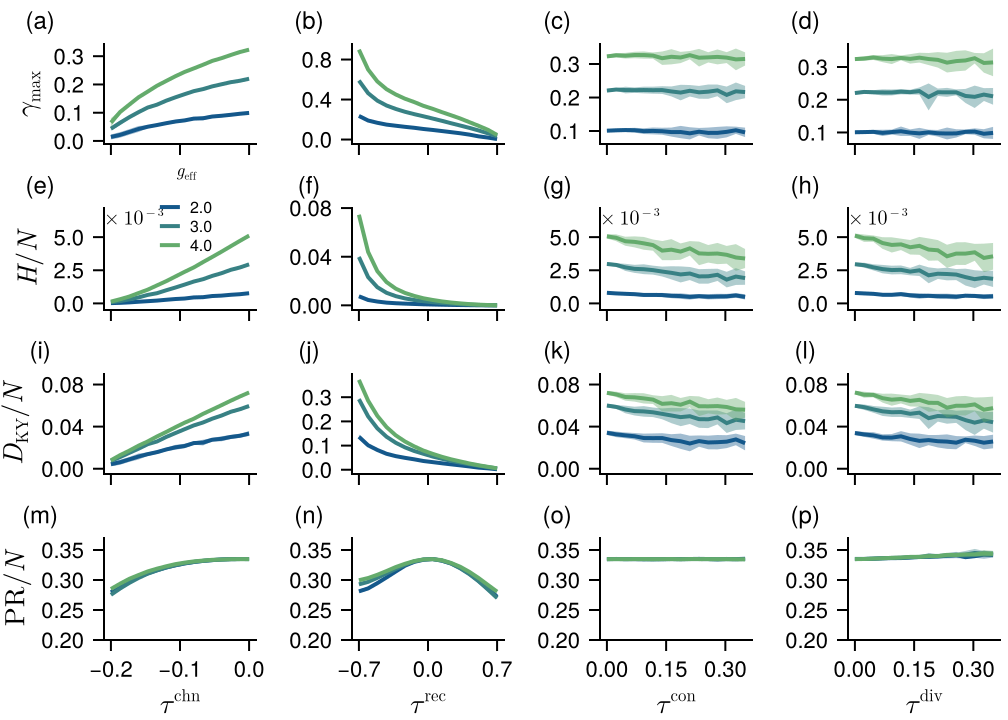

CairoMakie.Screen{IMAGE}


In [ ]:
# Run LSHKYDAllMotifs.jl
data = load("results/LSHKYDAllMotifs.jld2")
N = data["N"]
g_eff_vec = data["g_eff_vec"]

f1 = Figure(size=(7*72, 5.0*72), figure_padding=(1f0, 4f0, 2f0, 3f0))
cmap = to_colormap(:navia10)
g_colors = cmap[3:2:7]
motifs = ["Chain", "Reciprocal", "Convergent", "Divergent"]
metrics = ["Lmax", "H", "KYD", "PR"]
ylabels = [L"\gamma_{\max}", L"H/N", L"D_{\text{KY}}/N", L"\text{PR}/N"]
xlabels = [L"τ^{\text{chn}}", L"τ^{\text{rec}}", L"τ^{\text{con}}", L"τ^{\text{div}}"]
axes_grid = Matrix{Any}(undef, 4, 4)

for (col_idx, motif_key) in enumerate(motifs)
    m_data = data[motif_key]
    tau = m_data.τ
    g_vals = g_eff_vec

    for (row_idx, metric) in enumerate(metrics)

        # Create Axis
        ax = Axis(f1[row_idx, col_idx], xticklabelsize=11, yticklabelsize=11)
        axes_grid[row_idx, col_idx] = ax

        # Styling: Labels only on edges
        if col_idx == 1
            ax.ylabel = ylabels[row_idx]
            ax.xticks = [-0.2, -0.1, 0.0]
        elseif col_idx == 2
            ax.xticks = [-0.7, 0.0, 0.7]
        end

        if row_idx == 2 && col_idx != 2
            ax.limits = (nothing, nothing, -0.0005, 0.0072)
            ax.ytickformat = values -> string.(round.(values .* 1000; digits=1))
            text!(ax, 0.0, 0.8; text=L"\times 10^{-3}", space=:relative,
                align=(:left, :bottom), fontsize=10)
        elseif row_idx == 3 && col_idx != 2
            ax.limits = (nothing, nothing, -0.005, 0.09)
            ax.yticks = [0.0, 0.04, 0.08]
        elseif row_idx == 4
            ax.xlabel = xlabels[col_idx]
            ax.limits = (nothing, nothing, 0.2, 0.37)
        end

        if row_idx == 1 && col_idx == 2
            ax.yticks = [0.0, 0.4, 0.8]
        elseif row_idx == 2 && col_idx == 2
            ax.yticks = [0.0, 0.04, 0.08]
        end

        if row_idx != 4
            ax.xticklabelsvisible = false
        end

        if col_idx == 3 || col_idx == 4
            ax.xticks = [0.0, 0.15, 0.3]
        end

        # Plot Lines for each g value
        for i in eachindex(g_vals)
            vecs = retrieve_LS_KSE_KYD(m_data, i)

            # Map metric string to tuple index in get_vecs return
            # (Lmax, Lmax_s, H, H_s, KYD, KYD_s, PR, PR_s)
            # indices: 1&2, 3&4, 5&6, 7&8
            mean_idx = (row_idx - 1) * 2 + 1
            std_idx = mean_idx + 1

            y_mean = vecs[mean_idx]
            y_std = vecs[std_idx]

            if row_idx ≥ 2
                y_mean ./= N
                y_std ./= N
            end

            color = (g_colors[i], 0.4)

            lower = y_mean .- y_std
            upper = y_mean .+ y_std

            valid_idx = .!isnan.(y_mean) .& .!isnan.(y_std)
            if any(valid_idx)
                band!(ax, tau[valid_idx], lower[valid_idx], upper[valid_idx];
                    color=color)

                lines!(ax, tau[valid_idx], y_mean[valid_idx];
                    color=g_colors[i], linewidth=2.0,
                    label=(row_idx == 2 && col_idx == 1) ? "$(g_vals[i])" : nothing)
            end
        end
    end
end

panel_labels = ["(a)" "(b)" "(c)" "(d)";
                "(e)" "(f)" "(g)" "(h)";
                "(i)" "(j)" "(k)" "(l)";
                "(m)" "(n)" "(o)" "(p)"]

for row in 1:4, col in 1:4
    if row == 1
        Label(f1[row, col, TopLeft()], panel_labels[row, col];
            fontsize=12, padding=(0f0, 13f0, 5f0, 0f0))
    else
        Label(f1[row, col, TopLeft()], panel_labels[row, col];
            fontsize=12, padding=(0f0, 13f0, 5f0, 0f0))
    end
end

rowgap!(f1.layout, 8)
axislegend(axes_grid[2, 1], L"g_{\text{eff}}", position=(0.6,-0.8), framevisible=false, 
    titlesize=9, labelsize=8, patchsize=(10, 7), rowgap=0.2)
# save("images/LyapunovSpectrumAllMotifs.pdf", f1, pt_per_unit=1)
display(f1)